In [ ]:
from google.colab import files

uploaded = files.upload()

Saving data_banknote_authentication.txt to data_banknote_authentication.txt


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=column_names
)

df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.shape

(1372, 5)

In [ ]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [ ]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df["Class"].value_counts()

,count
Class,
0,762
1,610


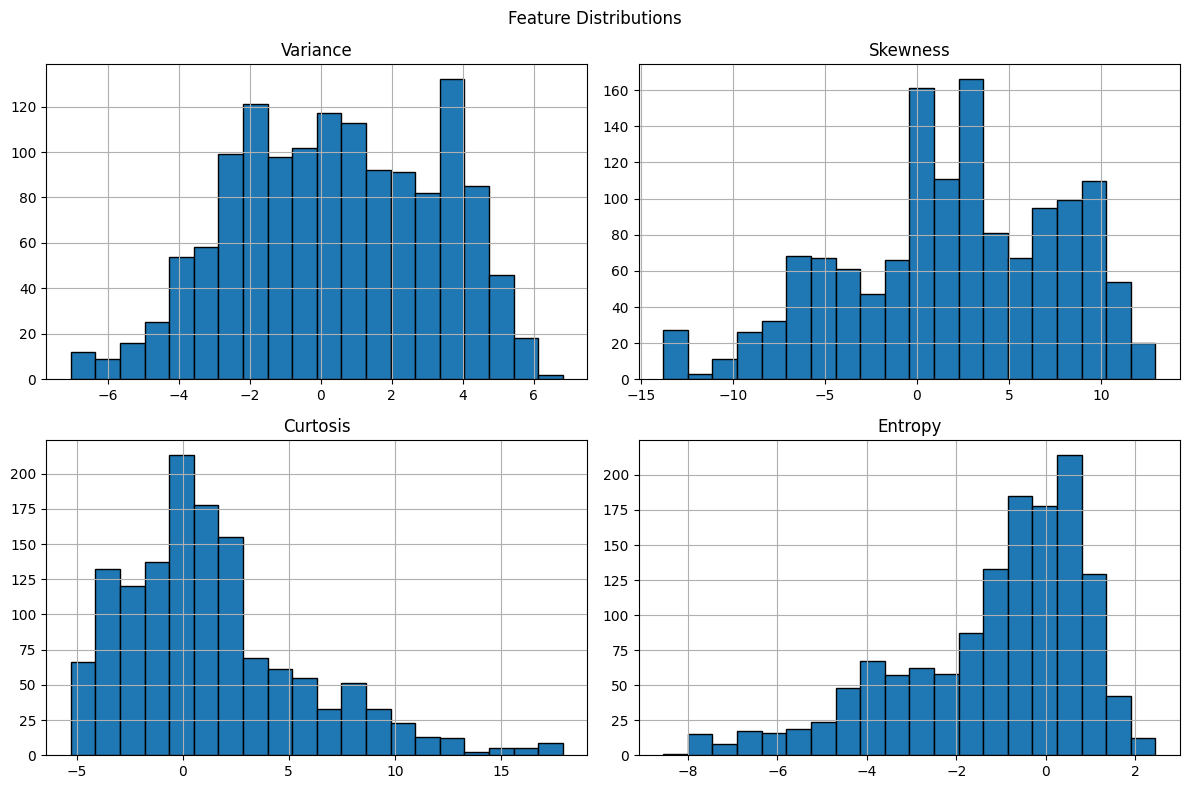

In [ ]:
feature_columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy"
]

df[feature_columns].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

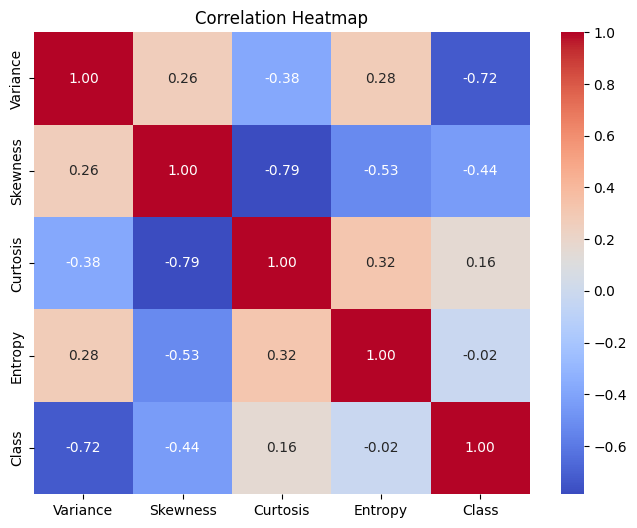

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

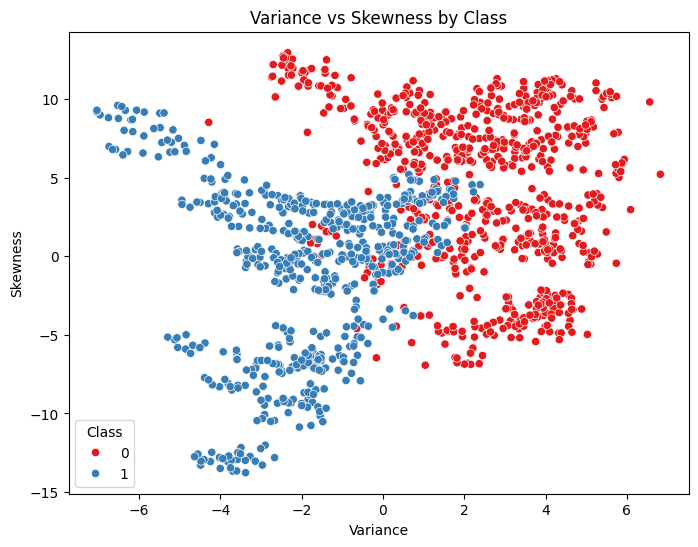

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Variance vs Skewness by Class")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.show()

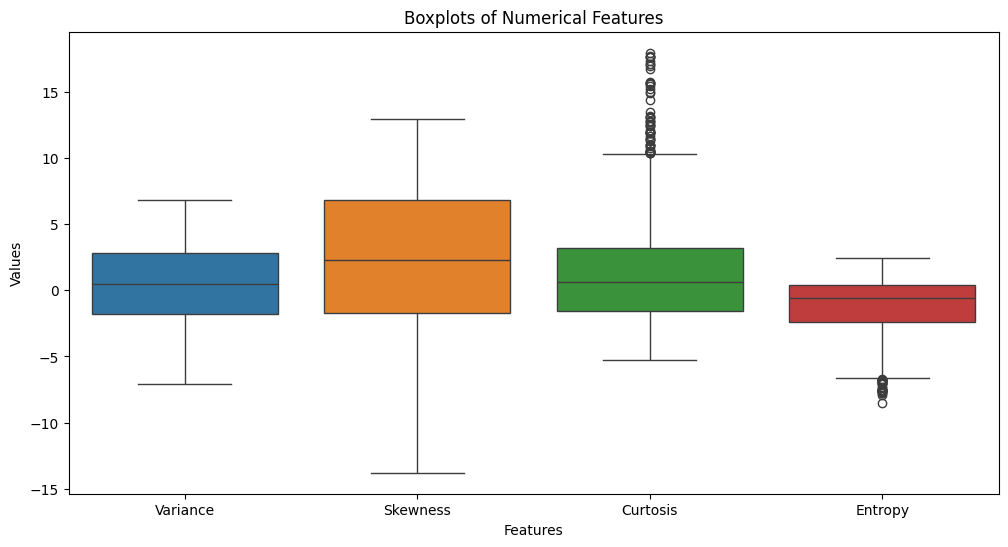

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[feature_columns])

plt.title("Boxplots of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

In [ ]:
# ============================================================
# TASK 3: DATA PREPROCESSING
# ============================================================

print("\n" + "=" * 70)
print("TASK 3: DATA PREPROCESSING")
print("=" * 70)

# Separate input features and target
X = df[feature_columns].values
y = df["Class"].values

print("\nOriginal Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)


# ------------------------------------------------------------
# TRAIN-TEST SPLIT: 80% TRAINING, 20% TESTING
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


# ------------------------------------------------------------
# FEATURE NORMALIZATION
# ------------------------------------------------------------

scaler = StandardScaler()

# Learn mean and standard deviation only from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to testing data
X_test_scaled = scaler.transform(X_test)

print("\nFeature Normalization Completed")

print("\nMean of Scaled Training Features:")
print(np.mean(X_train_scaled, axis=0))

print("\nStandard Deviation of Scaled Training Features:")
print(np.std(X_train_scaled, axis=0))


TASK 3: DATA PREPROCESSING

Original Feature Matrix Shape: (1372, 4)
Target Vector Shape: (1372,)

Training Samples: 1097
Testing Samples: 275

Feature Normalization Completed

Mean of Scaled Training Features:
[-8.72390380e-17 -3.24666861e-16 -5.25458336e-16  5.76465848e-16]

Standard Deviation of Scaled Training Features:
[1. 1. 1. 1.]


In [ ]:
# ============================================================
# TASK 4: SINGLE LAYER PERCEPTRON FROM SCRATCH
# ============================================================

print("\n" + "=" * 70)
print("TASK 4: PERCEPTRON IMPLEMENTATION FROM SCRATCH")
print("=" * 70)


class SingleLayerPerceptron:

    def __init__(self, learning_rate=0.01, epochs=50):

        # Learning rate controls update size
        self.learning_rate = learning_rate

        # Number of complete passes through training dataset
        self.epochs = epochs

        # Model parameters
        self.weights = None
        self.bias = 0.0

        # Store training history
        self.errors_history = []
        self.weights_history = []
        self.bias_history = []


    # --------------------------------------------------------
    # STEP ACTIVATION FUNCTION
    # --------------------------------------------------------

    def activation(self, z):

        return 1 if z >= 0 else 0


    # --------------------------------------------------------
    # FORWARD PROPAGATION FOR ONE SAMPLE
    # --------------------------------------------------------

    def predict_one(self, x):

        # Weighted sum:
        # z = w^T x + b
        z = np.dot(x, self.weights) + self.bias

        # Apply step activation
        return self.activation(z)


    # --------------------------------------------------------
    # TRAINING FUNCTION
    # --------------------------------------------------------

    def fit(self, X, y):

        # Initialize all weights to zero
        self.weights = np.zeros(X.shape[1])

        # Initialize bias to zero
        self.bias = 0.0

        # Reset histories
        self.errors_history = []
        self.weights_history = []
        self.bias_history = []

        # Repeat training for given number of epochs
        for epoch in range(self.epochs):

            misclassified = 0

            # Visit every training sample
            for xi, target in zip(X, y):

                # Forward propagation
                prediction = self.predict_one(xi)

                # Calculate error
                error = target - prediction

                # If prediction is wrong
                if error != 0:

                    misclassified += 1

                    # Perceptron weight update rule
                    self.weights += (
                        self.learning_rate
                        * error
                        * xi
                    )

                    # Bias update rule
                    self.bias += (
                        self.learning_rate
                        * error
                    )

            # Save epoch information
            self.errors_history.append(misclassified)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            # Display required training information
            print(
                f"Epoch {epoch + 1:3d} | "
                f"Misclassified Samples = {misclassified:3d} | "
                f"Weights = {np.round(self.weights, 4)} | "
                f"Bias = {self.bias:.4f}"
            )

        return self


    # --------------------------------------------------------
    # PREDICT MULTIPLE SAMPLES
    # --------------------------------------------------------

    def predict(self, X):

        predictions = []

        for x in X:
            prediction = self.predict_one(x)
            predictions.append(prediction)

        return np.array(predictions)


TASK 4: PERCEPTRON IMPLEMENTATION FROM SCRATCH


In [ ]:
# ============================================================
# TASK 5: MODEL TRAINING
# ============================================================

print("\n" + "=" * 70)
print("TASK 5: MODEL TRAINING")
print("=" * 70)

# Set training parameters
learning_rate = 0.01
epochs = 50

# Create the perceptron model
model = SingleLayerPerceptron(
    learning_rate=learning_rate,
    epochs=epochs
)

# Train the model using normalized training data
model.fit(
    X_train_scaled,
    y_train
)


TASK 5: MODEL TRAINING
Epoch   1 | Misclassified Samples =  51 | Weights = [-0.0602 -0.0841 -0.063   0.0023] | Bias = -0.0300
Epoch   2 | Misclassified Samples =  32 | Weights = [-0.0863 -0.1022 -0.0766  0.0074] | Bias = -0.0300
Epoch   3 | Misclassified Samples =  27 | Weights = [-0.0993 -0.1133 -0.082   0.0055] | Bias = -0.0400
Epoch   4 | Misclassified Samples =  25 | Weights = [-0.0799 -0.1184 -0.1063 -0.0073] | Bias = -0.0500
Epoch   5 | Misclassified Samples =  27 | Weights = [-0.1099 -0.1249 -0.1031 -0.0068] | Bias = -0.0400
Epoch   6 | Misclassified Samples =  20 | Weights = [-0.1045 -0.1264 -0.1146  0.0109] | Bias = -0.0600
Epoch   7 | Misclassified Samples =  20 | Weights = [-0.107  -0.1469 -0.1033  0.0077] | Bias = -0.0600
Epoch   8 | Misclassified Samples =  23 | Weights = [-0.1152 -0.1481 -0.1144 -0.0082] | Bias = -0.0500
Epoch   9 | Misclassified Samples =  21 | Weights = [-0.1152 -0.1396 -0.1341 -0.0017] | Bias = -0.0600
Epoch  10 | Misclassified Samples =  22 | Weights

In [ ]:
# ============================================================
# TASK 6: MODEL EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("TASK 6: MODEL EVALUATION")
print("=" * 70)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

cm = confusion_matrix(y_test, y_pred)


print("\nPerformance Metrics")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)




TASK 6: MODEL EVALUATION

Performance Metrics
Accuracy  : 0.9818
Precision : 0.9606
Recall    : 1.0000
F1-score  : 0.9799

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       153
           1       0.96      1.00      0.98       122

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



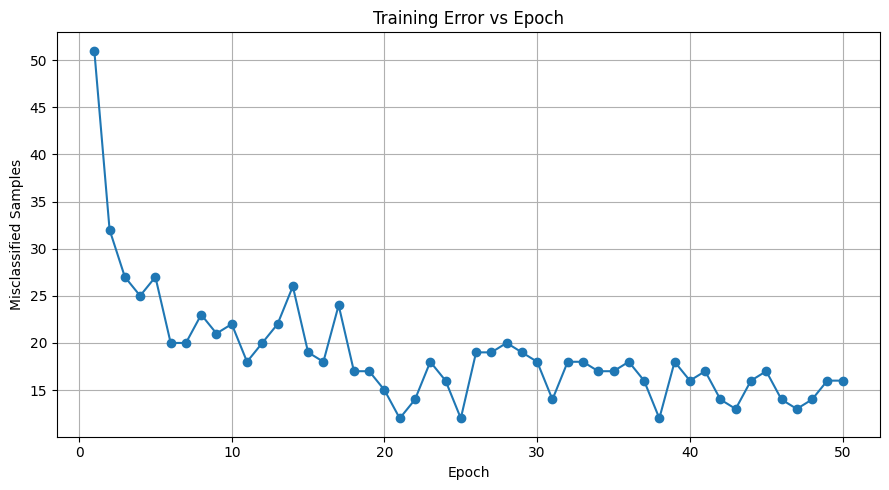

In [ ]:
# ============================================================
# MANDATORY PLOT 1:
# TRAINING ERROR VS EPOCH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, epochs + 1),
    model.errors_history,
    marker="o"
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)
plt.tight_layout()
plt.show()


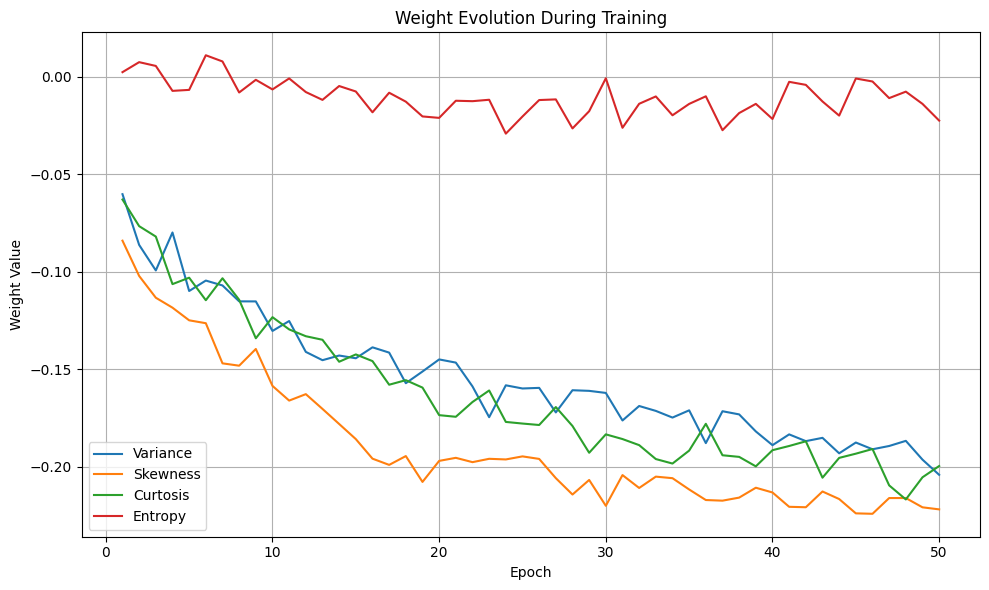

In [ ]:
# ============================================================
# MANDATORY PLOT 2:
# WEIGHT EVOLUTION
# ============================================================

weights_history = np.array(
    model.weights_history
)

plt.figure(figsize=(10, 6))

for i, feature in enumerate(feature_columns):

    plt.plot(
        range(1, epochs + 1),
        weights_history[:, i],
        label=feature
    )

plt.title("Weight Evolution During Training")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

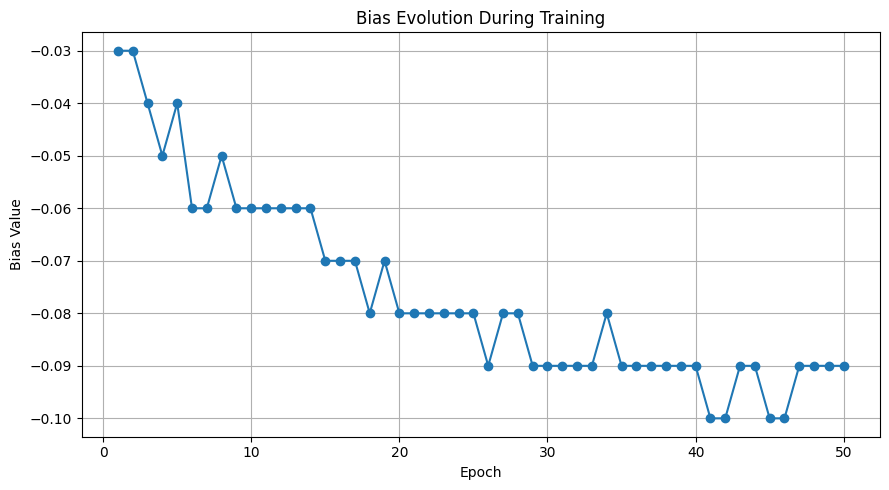

In [ ]:
# ============================================================
# MANDATORY PLOT 3:
# BIAS EVOLUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, epochs + 1),
    model.bias_history,
    marker="o"
)

plt.title("Bias Evolution During Training")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)
plt.tight_layout()
plt.show()



LEARNING RATE COMPARISON

Training with Learning Rate = 0.001
Epoch   1 | Misclassified Samples =  51 | Weights = [-0.006  -0.0084 -0.0063  0.0002] | Bias = -0.0030
Epoch   2 | Misclassified Samples =  32 | Weights = [-0.0086 -0.0102 -0.0077  0.0007] | Bias = -0.0030
Epoch   3 | Misclassified Samples =  27 | Weights = [-0.0099 -0.0113 -0.0082  0.0005] | Bias = -0.0040
Epoch   4 | Misclassified Samples =  25 | Weights = [-0.008  -0.0118 -0.0106 -0.0007] | Bias = -0.0050
Epoch   5 | Misclassified Samples =  27 | Weights = [-0.011  -0.0125 -0.0103 -0.0007] | Bias = -0.0040
Epoch   6 | Misclassified Samples =  20 | Weights = [-0.0105 -0.0126 -0.0115  0.0011] | Bias = -0.0060
Epoch   7 | Misclassified Samples =  20 | Weights = [-0.0107 -0.0147 -0.0103  0.0008] | Bias = -0.0060
Epoch   8 | Misclassified Samples =  23 | Weights = [-0.0115 -0.0148 -0.0114 -0.0008] | Bias = -0.0050
Epoch   9 | Misclassified Samples =  21 | Weights = [-0.0115 -0.014  -0.0134 -0.0002] | Bias = -0.0060
Epoch  10 

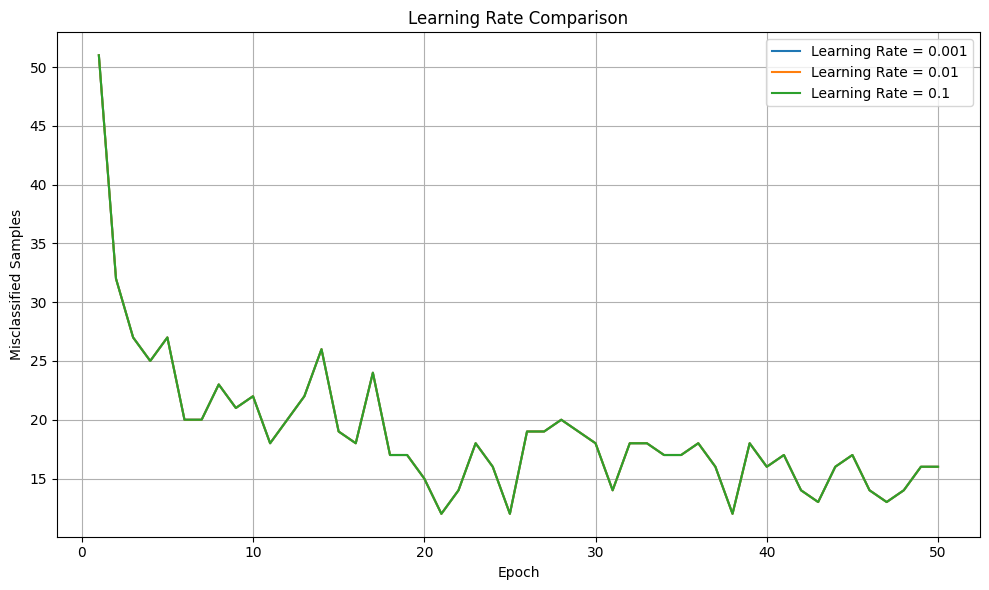


Learning Rate Performance Comparison:
 Learning Rate  Accuracy  Precision  Recall  F1-score  Final Training Errors
         0.001  0.981818    0.96063     1.0   0.97992                     16
         0.010  0.981818    0.96063     1.0   0.97992                     16
         0.100  0.981818    0.96063     1.0   0.97992                     16


In [ ]:
# ============================================================
# LEARNING RATE COMPARISON
# Required rates: 0.001, 0.01, 0.1
# ============================================================

print("\n" + "=" * 70)
print("LEARNING RATE COMPARISON")
print("=" * 70)

learning_rates = [
    0.001,
    0.01,
    0.1
]

lr_models = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    temp_model = SingleLayerPerceptron(
        learning_rate=lr,
        epochs=epochs
    )

    temp_model.fit(
        X_train_scaled,
        y_train
    )

    lr_models[lr] = temp_model

    plt.plot(
        range(1, epochs + 1),
        temp_model.errors_history,
        label=f"Learning Rate = {lr}"
    )

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# LEARNING RATE PERFORMANCE TABLE
# ============================================================

lr_results = []

for lr, temp_model in lr_models.items():

    temp_predictions = temp_model.predict(
        X_test_scaled
    )

    lr_results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy_score(
            y_test,
            temp_predictions
        ),
        "Precision": precision_score(
            y_test,
            temp_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            temp_predictions,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            temp_predictions,
            zero_division=0
        ),
        "Final Training Errors":
            temp_model.errors_history[-1]
    })

lr_results_df = pd.DataFrame(lr_results)

print("\nLearning Rate Performance Comparison:")
print(lr_results_df.to_string(index=False))


In [ ]:
# ============================================================
# PERFORMANCE TABLE 1:
# TRAINING SUMMARY
# ============================================================

training_summary = pd.DataFrame({
    "Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Training Samples",
        "Testing Samples",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        df.shape[0],
        "80% / 20%",
        X_train.shape[0],
        X_test.shape[0],
        learning_rate,
        epochs,
        np.round(model.weights, 4),
        round(model.bias, 4),
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

print("\n" + "=" * 70)
print("TRAINING SUMMARY TABLE")
print("=" * 70)

print(
    training_summary.to_string(
        index=False
    )
)


# ============================================================
# PERFORMANCE TABLE 2:
# EPOCH-WISE LEARNING
# ============================================================

epoch_wise_table = pd.DataFrame({
    "Epoch": range(1, epochs + 1),

    "Errors":
        model.errors_history,

    "Weight 1":
        weights_history[:, 0],

    "Weight 2":
        weights_history[:, 1],

    "Weight 3":
        weights_history[:, 2],

    "Weight 4":
        weights_history[:, 3],

    "Bias":
        model.bias_history
})

print("\n" + "=" * 70)
print("EPOCH-WISE LEARNING TABLE")
print("=" * 70)

print(
    epoch_wise_table.to_string(
        index=False
    )
)



TRAINING SUMMARY TABLE
       Parameter                               Value
    Dataset Size                                1372
Train/Test Split                           80% / 20%
Training Samples                                1097
 Testing Samples                                 275
   Learning Rate                                0.01
          Epochs                                  50
   Final Weights [-0.204, -0.2218, -0.1995, -0.0226]
      Final Bias                               -0.09
        Accuracy                              0.9818
       Precision                              0.9606
          Recall                                 1.0
        F1-score                              0.9799

EPOCH-WISE LEARNING TABLE
 Epoch  Errors  Weight 1  Weight 2  Weight 3  Weight 4  Bias
     1      51 -0.060249 -0.084077 -0.063000  0.002269 -0.03
     2      32 -0.086251 -0.102153 -0.076638  0.007392 -0.03
     3      27 -0.099324 -0.113308 -0.081976  0.005451 -0.04
     4      25 -


ADDITIONAL TASK 1: STEP VS SIGMOID ACTIVATION


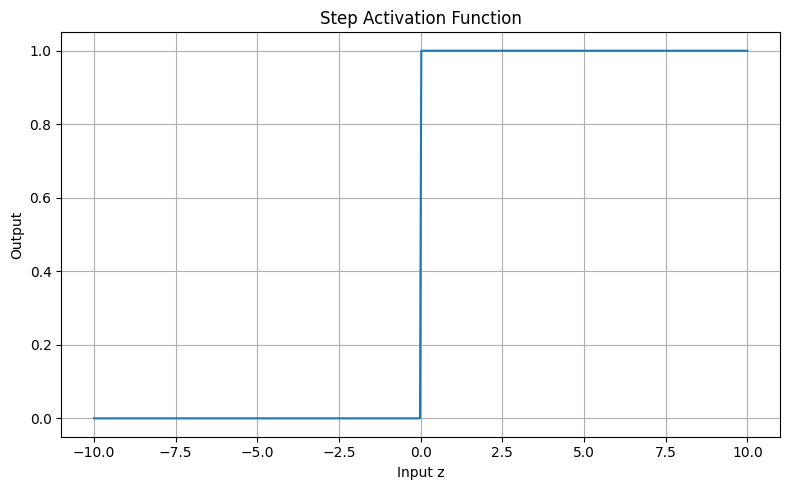

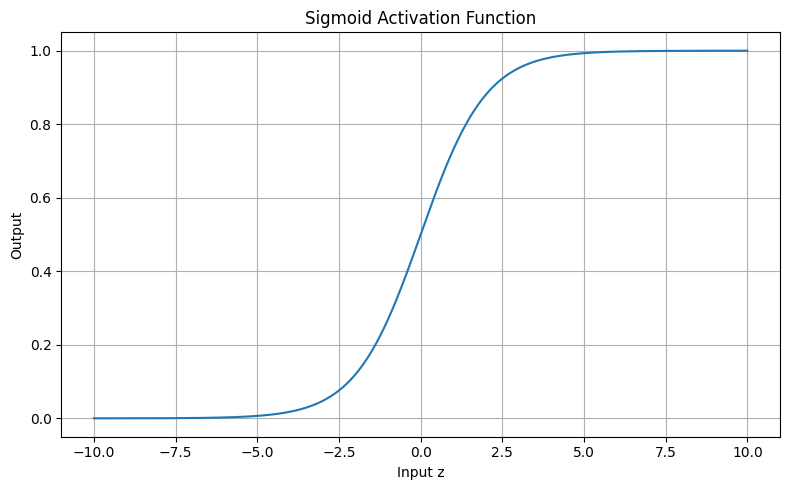


Step vs Sigmoid Comparison:
               Property          Step Function          Sigmoid Function
           Output Range                 {0, 1}                    (0, 1)
                 Nature Abrupt / Discontinuous       Smooth / Continuous
         Differentiable            No at z = 0                       Yes
Gradient-based Learning           Not suitable                  Suitable
            Typical Use   Classical Perceptron Binary probability output

Interpretation:

The Step activation function gives only two outputs: 0 or 1.
Its output changes abruptly at z = 0.

The Sigmoid activation function changes smoothly between 0 and 1.

The Step function is not used for gradient-based deep learning
because it is not differentiable at z = 0 and its derivative is
zero almost everywhere else. Therefore, it does not provide a useful
gradient for backpropagation.

Sigmoid is differentiable and can support gradient-based optimization,
although modern hidden layers often use functions 

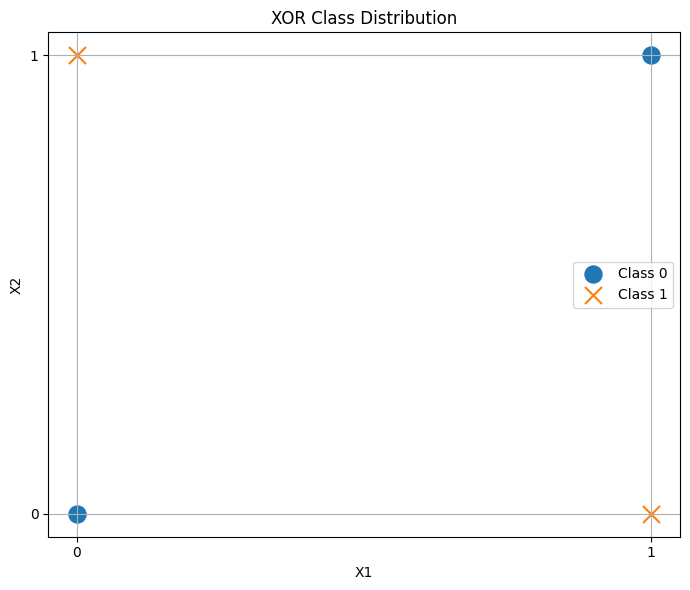

Epoch   1 | Misclassified Samples =   3 | Weights = [-0.1  0. ] | Bias = -0.1000
Epoch   2 | Misclassified Samples =   3 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   3 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   4 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   5 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   6 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   7 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   8 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch   9 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch  10 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch  11 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch  12 | Misclassified Samples =   4 | Weights = [-0.1  0. ] | Bias = 0.0000
Epoch  13 | Misclassified Samples =   4

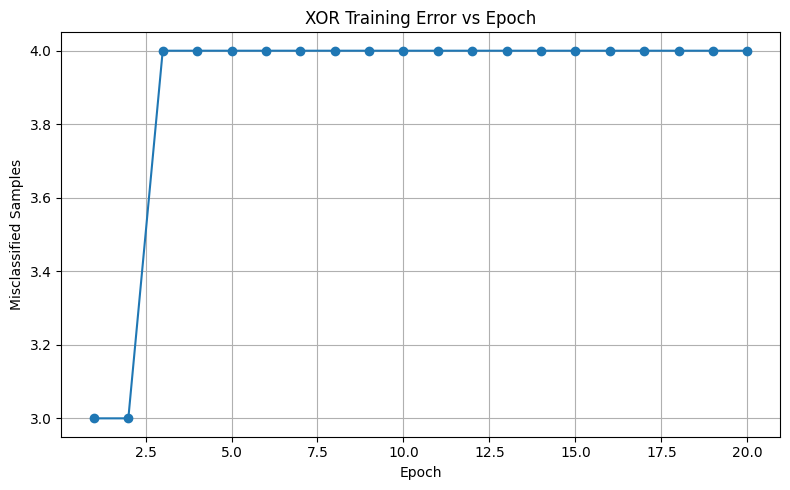


Interpretation:

XOR is not linearly separable.

Class 0 occurs at:
(0, 0) and (1, 1)

Class 1 occurs at:
(0, 1) and (1, 0)

No single straight line can separate these two classes.

A Single Layer Perceptron creates only one linear decision boundary.
Therefore, it cannot perfectly solve the XOR problem.

A Multilayer Perceptron with hidden neurons can solve XOR by learning
non-linear combinations of the inputs.


ADDITIONAL TASK 5: EFFECT OF FEATURE NORMALIZATION

Training WITHOUT Normalization
Epoch   1 | Misclassified Samples =  63 | Weights = [-0.2735 -0.1785 -0.1938 -0.0284] | Bias = 0.2100
Epoch   2 | Misclassified Samples =  37 | Weights = [-0.4042 -0.2721 -0.2643 -0.1107] | Bias = 0.3000
Epoch   3 | Misclassified Samples =  31 | Weights = [-0.411  -0.3424 -0.3324 -0.0695] | Bias = 0.3700
Epoch   4 | Misclassified Samples =  22 | Weights = [-0.4604 -0.3409 -0.3613 -0.0246] | Bias = 0.3900
Epoch   5 | Misclassified Samples =  19 | Weights = [-0.4809 -0.3588 -0.3689 -0.0497] | Bia

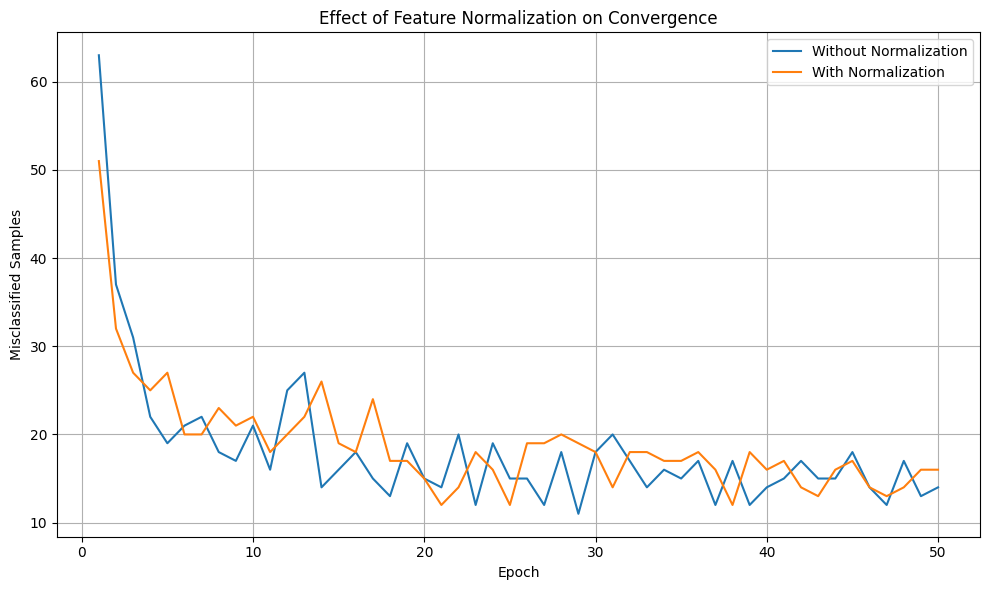


Normalization Performance Comparison:
                Model  Accuracy  Precision   Recall  F1-score  Final Training Errors
Without Normalization  0.978182   0.991525 0.959016   0.97500                     14
   With Normalization  0.981818   0.960630 1.000000   0.97992                     16

Average Misclassified Samples Across Epochs:
Without Normalization: 18.14
With Normalization: 18.9

Interpretation:

Feature normalization places numerical features on a comparable scale.

Without normalization, features with larger numerical magnitudes can
produce larger perceptron weight updates because the update rule directly
contains the input vector x.

With normalization, the features are standardized using the training-set
statistics. This can make the learning process more stable and can change
the convergence behaviour.

The final conclusion should be based on the generated error curves and
performance table. Compare the number of misclassified samples across
epochs and the final Accura

In [ ]:
# ============================================================
# ADDITIONAL TASK 1
# COMPARE STEP AND SIGMOID ACTIVATION FUNCTIONS
# ============================================================

print("\n" + "=" * 70)
print("ADDITIONAL TASK 1: STEP VS SIGMOID ACTIVATION")
print("=" * 70)


# Step Activation Function
def step_function(z):
    return np.where(z >= 0, 1, 0)


# Sigmoid Activation Function
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))


# Generate values from -10 to 10
z_values = np.linspace(-10, 10, 500)

# Calculate outputs
step_outputs = step_function(z_values)
sigmoid_outputs = sigmoid_function(z_values)


# Plot Step Function
plt.figure(figsize=(8, 5))

plt.plot(
    z_values,
    step_outputs
)

plt.title("Step Activation Function")
plt.xlabel("Input z")
plt.ylabel("Output")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot Sigmoid Function
plt.figure(figsize=(8, 5))

plt.plot(
    z_values,
    sigmoid_outputs
)

plt.title("Sigmoid Activation Function")
plt.xlabel("Input z")
plt.ylabel("Output")
plt.grid(True)
plt.tight_layout()
plt.show()


# Comparison Table
activation_comparison = pd.DataFrame({

    "Property": [
        "Output Range",
        "Nature",
        "Differentiable",
        "Gradient-based Learning",
        "Typical Use"
    ],

    "Step Function": [
        "{0, 1}",
        "Abrupt / Discontinuous",
        "No at z = 0",
        "Not suitable",
        "Classical Perceptron"
    ],

    "Sigmoid Function": [
        "(0, 1)",
        "Smooth / Continuous",
        "Yes",
        "Suitable",
        "Binary probability output"
    ]
})

print("\nStep vs Sigmoid Comparison:")
print(activation_comparison.to_string(index=False))


print("\nInterpretation:")
print("""
The Step activation function gives only two outputs: 0 or 1.
Its output changes abruptly at z = 0.

The Sigmoid activation function changes smoothly between 0 and 1.

The Step function is not used for gradient-based deep learning
because it is not differentiable at z = 0 and its derivative is
zero almost everywhere else. Therefore, it does not provide a useful
gradient for backpropagation.

Sigmoid is differentiable and can support gradient-based optimization,
although modern hidden layers often use functions such as ReLU because
sigmoid can suffer from vanishing gradients.
""")


# ============================================================
# ADDITIONAL TASK 4
# WHY A SINGLE LAYER PERCEPTRON CANNOT SOLVE XOR
# ============================================================

print("\n" + "=" * 70)
print("ADDITIONAL TASK 4: XOR PROBLEM")
print("=" * 70)


# XOR Input Data
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])


# XOR Target Output
y_xor = np.array([
    0,
    1,
    1,
    0
])


# Display XOR Truth Table
xor_table = pd.DataFrame({

    "Input X1": X_xor[:, 0],
    "Input X2": X_xor[:, 1],
    "XOR Output": y_xor
})

print("\nXOR Truth Table:")
print(xor_table.to_string(index=False))


# Plot XOR Data
plt.figure(figsize=(7, 6))

plt.scatter(
    X_xor[y_xor == 0, 0],
    X_xor[y_xor == 0, 1],
    marker="o",
    s=150,
    label="Class 0"
)

plt.scatter(
    X_xor[y_xor == 1, 0],
    X_xor[y_xor == 1, 1],
    marker="x",
    s=150,
    label="Class 1"
)

plt.title("XOR Class Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Train our Single Layer Perceptron on XOR
xor_model = SingleLayerPerceptron(
    learning_rate=0.1,
    epochs=20
)

xor_model.fit(
    X_xor,
    y_xor
)


# XOR Predictions
xor_predictions = xor_model.predict(X_xor)


# Create result table
xor_results = pd.DataFrame({

    "X1": X_xor[:, 0],
    "X2": X_xor[:, 1],
    "Actual Output": y_xor,
    "Predicted Output": xor_predictions
})

print("\nXOR Prediction Results:")
print(xor_results.to_string(index=False))


xor_accuracy = accuracy_score(
    y_xor,
    xor_predictions
)

print(
    "\nXOR Accuracy:",
    xor_accuracy
)


# Plot XOR Training Errors
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 21),
    xor_model.errors_history,
    marker="o"
)

plt.title("XOR Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)
plt.tight_layout()
plt.show()


print("\nInterpretation:")
print("""
XOR is not linearly separable.

Class 0 occurs at:
(0, 0) and (1, 1)

Class 1 occurs at:
(0, 1) and (1, 0)

No single straight line can separate these two classes.

A Single Layer Perceptron creates only one linear decision boundary.
Therefore, it cannot perfectly solve the XOR problem.

A Multilayer Perceptron with hidden neurons can solve XOR by learning
non-linear combinations of the inputs.
""")


# ============================================================
# ADDITIONAL TASK 5
# EFFECT OF FEATURE NORMALIZATION ON MODEL CONVERGENCE
# ============================================================

print("\n" + "=" * 70)
print("ADDITIONAL TASK 5: EFFECT OF FEATURE NORMALIZATION")
print("=" * 70)


# ------------------------------------------------------------
# MODEL A: WITHOUT NORMALIZATION
# ------------------------------------------------------------

print("\nTraining WITHOUT Normalization")

model_without_normalization = SingleLayerPerceptron(
    learning_rate=0.01,
    epochs=50
)

model_without_normalization.fit(
    X_train,
    y_train
)


# Predictions without normalization
pred_without_normalization = (
    model_without_normalization.predict(X_test)
)


# Performance without normalization
accuracy_without = accuracy_score(
    y_test,
    pred_without_normalization
)

precision_without = precision_score(
    y_test,
    pred_without_normalization,
    zero_division=0
)

recall_without = recall_score(
    y_test,
    pred_without_normalization,
    zero_division=0
)

f1_without = f1_score(
    y_test,
    pred_without_normalization,
    zero_division=0
)


# ------------------------------------------------------------
# MODEL B: WITH NORMALIZATION
# ------------------------------------------------------------

print("\nTraining WITH Normalization")

model_with_normalization = SingleLayerPerceptron(
    learning_rate=0.01,
    epochs=50
)

model_with_normalization.fit(
    X_train_scaled,
    y_train
)


# Predictions with normalization
pred_with_normalization = (
    model_with_normalization.predict(X_test_scaled)
)


# Performance with normalization
accuracy_with = accuracy_score(
    y_test,
    pred_with_normalization
)

precision_with = precision_score(
    y_test,
    pred_with_normalization,
    zero_division=0
)

recall_with = recall_score(
    y_test,
    pred_with_normalization,
    zero_division=0
)

f1_with = f1_score(
    y_test,
    pred_with_normalization,
    zero_division=0
)


# ------------------------------------------------------------
# CONVERGENCE COMPARISON GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 51),
    model_without_normalization.errors_history,
    label="Without Normalization"
)

plt.plot(
    range(1, 51),
    model_with_normalization.errors_history,
    label="With Normalization"
)

plt.title(
    "Effect of Feature Normalization on Convergence"
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PERFORMANCE COMPARISON TABLE
# ------------------------------------------------------------

normalization_comparison = pd.DataFrame({

    "Model": [
        "Without Normalization",
        "With Normalization"
    ],

    "Accuracy": [
        accuracy_without,
        accuracy_with
    ],

    "Precision": [
        precision_without,
        precision_with
    ],

    "Recall": [
        recall_without,
        recall_with
    ],

    "F1-score": [
        f1_without,
        f1_with
    ],

    "Final Training Errors": [
        model_without_normalization.errors_history[-1],
        model_with_normalization.errors_history[-1]
    ]
})


print("\nNormalization Performance Comparison:")

print(
    normalization_comparison.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# ADDITIONAL CONVERGENCE SUMMARY
# ------------------------------------------------------------

avg_errors_without = np.mean(
    model_without_normalization.errors_history
)

avg_errors_with = np.mean(
    model_with_normalization.errors_history
)

print("\nAverage Misclassified Samples Across Epochs:")

print(
    "Without Normalization:",
    round(avg_errors_without, 2)
)

print(
    "With Normalization:",
    round(avg_errors_with, 2)
)


print("\nInterpretation:")
print("""
Feature normalization places numerical features on a comparable scale.

Without normalization, features with larger numerical magnitudes can
produce larger perceptron weight updates because the update rule directly
contains the input vector x.

With normalization, the features are standardized using the training-set
statistics. This can make the learning process more stable and can change
the convergence behaviour.

The final conclusion should be based on the generated error curves and
performance table. Compare the number of misclassified samples across
epochs and the final Accuracy, Precision, Recall and F1-score before
stating whether normalization improved convergence for this run.
""")


# ============================================================
# FINAL ADDITIONAL TASK STATUS
# ============================================================

print("\n" + "=" * 70)
print("ALL ADDITIONAL TASKS COMPLETED")
print("=" * 70)

print("""
Additional Task 1:
Step vs Sigmoid comparison completed.

Additional Task 2:
Scikit-learn Perceptron comparison already included.

Additional Task 3:
Learning rates 0.001, 0.01 and 0.1 already compared.

Additional Task 4:
XOR limitation demonstrated and explained.

Additional Task 5:
Effect of feature normalization on convergence studied.
""")

In [ ]:
# ============================================================
# OPTIONAL:
# COMPARE WITH SCIKIT-LEARN PERCEPTRON
# ============================================================

print("\n" + "=" * 70)
print("SCIKIT-LEARN PERCEPTRON COMPARISON")
print("=" * 70)

# Import the Perceptron class from scikit-learn
from sklearn.linear_model import Perceptron as SklearnPerceptron

sk_model = SklearnPerceptron(
    eta0=0.01,
    max_iter=50,
    random_state=42
)

sk_model.fit(
    X_train_scaled,
    y_train
)

sk_pred = sk_model.predict(
    X_test_scaled
)

sk_accuracy = accuracy_score(
    y_test,
    sk_pred
)

sk_precision = precision_score(
    y_test,
    sk_pred,
    zero_division=0
)

sk_recall = recall_score(
    y_test,
    sk_pred,
    zero_division=0
)

sk_f1 = f1_score(
    y_test,
    sk_pred,
    zero_division=0
)


comparison_table = pd.DataFrame({

    "Model": [
        "Perceptron From Scratch",
        "Scikit-learn Perceptron"
    ],

    "Accuracy": [
        accuracy,
        sk_accuracy
    ],

    "Precision": [
        precision,
        sk_precision
    ],

    "Recall": [
        recall,
        sk_recall
    ],

    "F1-score": [
        f1,
        sk_f1
    ]
})

print("\nModel Comparison:")

print(
    comparison_table.to_string(
        index=False
    )
)


SCIKIT-LEARN PERCEPTRON COMPARISON

Model Comparison:
                  Model  Accuracy  Precision   Recall  F1-score
Perceptron From Scratch  0.981818   0.960630 1.000000  0.979920
Scikit-learn Perceptron  0.967273   0.944882 0.983607  0.963855


In [ ]:

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nFinal Learned Weights:")
print(model.weights)

print("\nFinal Learned Bias:")
print(model.bias)

print("\nFinal Test Performance:")
print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1-score  = {f1:.4f}")


EXPERIMENT COMPLETED SUCCESSFULLY

Final Learned Weights:
[-0.20404783 -0.22175178 -0.19953304 -0.02255425]

Final Learned Bias:
-0.09

Final Test Performance:
Accuracy  = 0.9818
Precision = 0.9606
Recall    = 1.0000
F1-score  = 0.9799
